<a href="https://colab.research.google.com/github/astridcvr/daily-ml-practice/blob/main/day_07_outliers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset loaded: 2823 rows, 26 columns
Columns: ['ORDERNUMBER', 'QUANTITYORDERED', 'PRICEEACH', 'ORDERLINENUMBER', 'SALES', 'ORDERDATE', 'STATUS', 'QTR_ID', 'MONTH_ID', 'YEAR_ID', 'PRODUCTLINE', 'MSRP', 'PRODUCTCODE', 'CUSTOMERNAME', 'PHONE', 'ADDRESSLINE1', 'CITY', 'POSTALCODE', 'COUNTRY', 'TERRITORY', 'CONTACTLASTNAME', 'CONTACTFIRSTNAME', 'DEALSIZE', 'TOTAL_ORDER_SALES', 'AVG_PRICE_ORDER', 'SALES_RATIO']


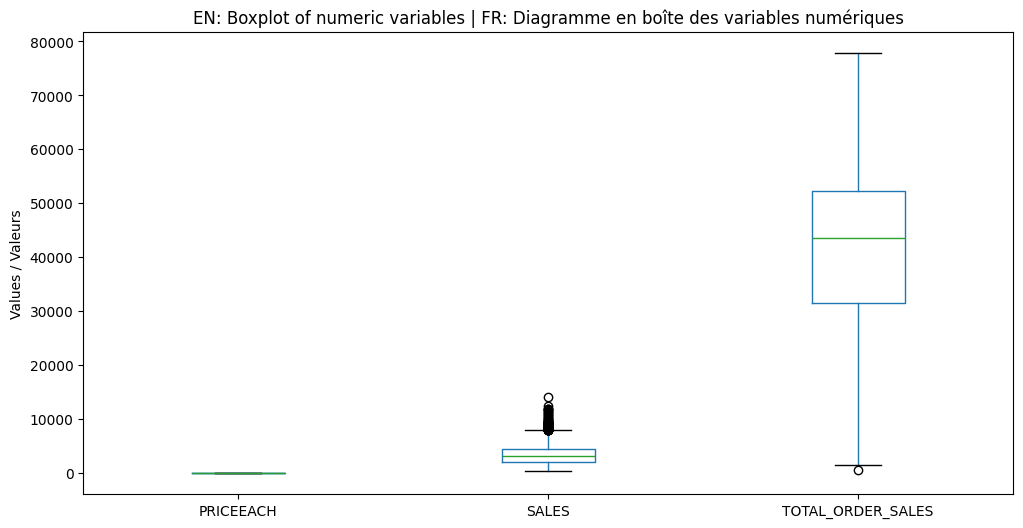


PRICEEACH outliers: 0
SALES outliers: 81

✅ Outliers capped successfully! / Valeurs aberrantes limitées avec succès !


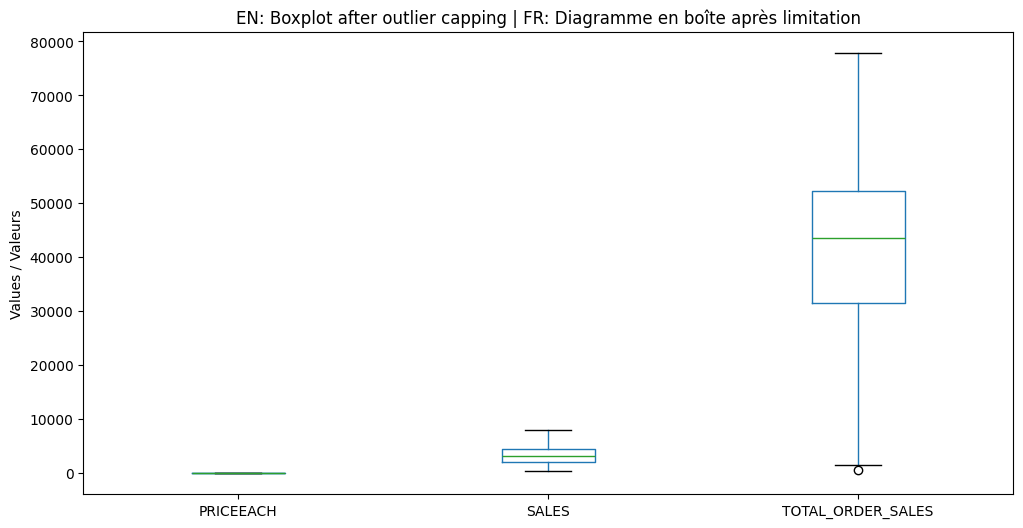


💾 File saved as 'sales_data_no_outliers.csv'
✅ Day 07 complete! / Jour 07 terminé !


In [1]:
# ===============================================================
# Day 07 – Outliers Detection / Détection des valeurs aberrantes
# ===============================================================

"""
🎯 Objective / Objectif :
EN: Detect and handle extreme values (outliers) in key numeric columns
    such as PRICEEACH and SALES to improve data quality.
FR: Détecter et traiter les valeurs extrêmes (valeurs aberrantes) dans
    les colonnes numériques clés comme PRICEEACH et SALES afin
    d'améliorer la qualité des données.

📘 Description :
EN: Outliers can distort statistical analyses and ML models. We’ll use
    the Interquartile Range (IQR) method to detect and optionally
    remove extreme values.
FR: Les valeurs aberrantes peuvent fausser les analyses statistiques
    et les modèles ML. Nous utiliserons la méthode de l’IQR pour
    détecter et éventuellement supprimer les valeurs extrêmes.

📅 Author / Auteur : Astrid Villalobos
📍 Montréal, QC
"""

# ===============================================================
# 1. Import libraries / Importer les bibliothèques
# ===============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ===============================================================
# 2. Load dataset / Charger le jeu de données
# ===============================================================

url = "https://raw.githubusercontent.com/astridcvr/daily-ml-practice/main/data/sales_data_features.csv"
df = pd.read_csv(url, encoding="latin1")

print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
print("Columns:", list(df.columns))

# ===============================================================
# 3. Visualize outliers / Visualiser les valeurs aberrantes
# ===============================================================

numeric_cols = ["PRICEEACH", "SALES", "TOTAL_ORDER_SALES"]

plt.figure(figsize=(12, 6))
df[numeric_cols].boxplot()
plt.title("EN: Boxplot of numeric variables | FR: Diagramme en boîte des variables numériques")
plt.ylabel("Values / Valeurs")
plt.grid(False)
plt.show()

# ===============================================================
# 4. Detect outliers with IQR / Détecter les valeurs aberrantes avec IQR
# ===============================================================

def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

outliers_price, low_p, high_p = detect_outliers_iqr(df, "PRICEEACH")
outliers_sales, low_s, high_s = detect_outliers_iqr(df, "SALES")

print(f"\nPRICEEACH outliers: {len(outliers_price)}")
print(f"SALES outliers: {len(outliers_sales)}")

# ===============================================================
# 5. Remove or cap outliers / Supprimer ou limiter les valeurs extrêmes
# ===============================================================

df_cleaned = df.copy()

# Option: Cap extreme values (replace with upper/lower limits)
df_cleaned["PRICEEACH"] = df_cleaned["PRICEEACH"].clip(lower=low_p, upper=high_p)
df_cleaned["SALES"] = df_cleaned["SALES"].clip(lower=low_s, upper=high_s)

print("\n✅ Outliers capped successfully! / Valeurs aberrantes limitées avec succès !")

# ===============================================================
# 6. Visualize after cleaning / Visualiser après nettoyage
# ===============================================================

plt.figure(figsize=(12, 6))
df_cleaned[numeric_cols].boxplot()
plt.title("EN: Boxplot after outlier capping | FR: Diagramme en boîte après limitation")
plt.ylabel("Values / Valeurs")
plt.grid(False)
plt.show()

# ===============================================================
# 7. Save cleaned dataset / Sauvegarder le jeu de données nettoyé
# ===============================================================

df_cleaned.to_csv("sales_data_no_outliers.csv", index=False)
print("\n💾 File saved as 'sales_data_no_outliers.csv'")
print("✅ Day 07 complete! / Jour 07 terminé !")
